In [1]:

import json
import matplotlib.pyplot as plt
from pathlib import Path
# warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
plt.style.use("default")   # quay về style mặc định (nền trắng)
import numpy as np
# set defaults for matplotlib
plt.rcParams['figure.figsize'] = (5, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.7
plt.rcParams['grid.linestyle'] = '--'
plt.rcParams['grid.color'] = 'gray'
plt.rcParams['lines.linewidth'] = 2
plt.rcParams['lines.markersize'] = 6
plt.rcParams['legend.frameon'] = True
plt.rcParams['legend.framealpha'] = 0.9
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['legend.loc'] = 'best'
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10

# Cấu hình font Times New Roman
plt.rcParams['font.family'] = 'Dejavu serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['mathtext.fontset'] = 'stix'  # Để hiển thị math text đúng
plt.rcParams['font.size'] = 12  # Font size mặc định

# Set style for better plots
# plt.style.use('seaborn-v0_8')
# sns.set_palette("husl")



In [2]:
# Option 1: Current colors (default)
COLOR_SCHEME_1 = {
    'gaussian_dql': 'tab:blue',
    'gaussian_ppo': 'tab:green', 
    'ql_diffusion': 'tab:orange',
    'ppo_diffusion': 'tab:red',
}

# Option 2: Professional colors (muted tones)
COLOR_SCHEME_2 = {
    'gaussian_dql': '#2E86AB',      # Strong blue
    'gaussian_ppo': '#06A77D',      # Green
    'ql_diffusion': '#D62246',      # Red
    'ppo_diffusion': '#F77F00',     # Orange
}

# Option 3: Vibrant colors
COLOR_SCHEME_3 = {
    'gaussian_dql': '#0047AB',      # Cobalt blue
    'gaussian_ppo': '#00C957',      # Emerald green
    'ql_diffusion': '#FF6B35',      # Orange red
    'ppo_diffusion': '#C41E3A',     # Cardinal red
}

# Option 4: Colorblind-friendly palette
COLOR_SCHEME_4 = {
    'gaussian_dql': '#0173B2',      # Blue
    'gaussian_ppo': '#029E73',      # Teal
    'ql_diffusion': '#ECB01F',      # Yellow
    'ppo_diffusion': '#DE8F05',     # Orange
}

# Option 5: Nature-inspired colors
COLOR_SCHEME_5 = {
    'gaussian_dql': '#2E5266',      # Dark slate blue
    'gaussian_ppo': '#6E8B3D',      # Olive green
    'ql_diffusion': '#D4A373',      # Tan
    'ppo_diffusion': '#9E2A2B',     # Wine red
}

SELECTED_SCHEME = 1  # Change this to 1, 2, 3, 4, or 5

# Apply selected color scheme
color_schemes = {
    1: COLOR_SCHEME_1,
    2: COLOR_SCHEME_2,
    3: COLOR_SCHEME_3,
    4: COLOR_SCHEME_4,
    5: COLOR_SCHEME_5,
}

# Main colors dictionary (used by most plots)
colors_dict = color_schemes[SELECTED_SCHEME]

# Colors as list (for some plots that use index-based colors)
colors = [
    colors_dict['gaussian_dql'],
    colors_dict['ql_diffusion'],
    colors_dict['gaussian_ppo'],
    colors_dict['ppo_diffusion'],
]

print("✓ Color scheme loaded successfully!")
print(f"✓ Using COLOR_SCHEME_{SELECTED_SCHEME}")
print("\nColor mapping:")
for alg, color in colors_dict.items():
    print(f"  {alg:20s} → {color}")

def smooth_rewards(rewards, window=200):
    from scipy.ndimage import uniform_filter1d
    return uniform_filter1d(rewards, size=window)

def get_algorithm_display_name(alg):
    """Convert algorithm names to display names for plots and legends"""
    mapping = {
        'ppo_diffusion': 'GSRM-DiPO',
        'ql_diffusion': 'GSRM-DiQL', 
        'gaussian_ppo': 'GSRM-PPO',
        'gaussian_dql': 'GSRM-DQL',
    }
    return mapping.get(alg, alg.replace('_', ' ').title())


✓ Color scheme loaded successfully!
✓ Using COLOR_SCHEME_1

Color mapping:
  gaussian_dql         → tab:blue
  gaussian_ppo         → tab:green
  ql_diffusion         → tab:orange
  ppo_diffusion        → tab:red


Colors:  ['tab:blue', 'tab:green', 'tab:red', 'tab:orange']


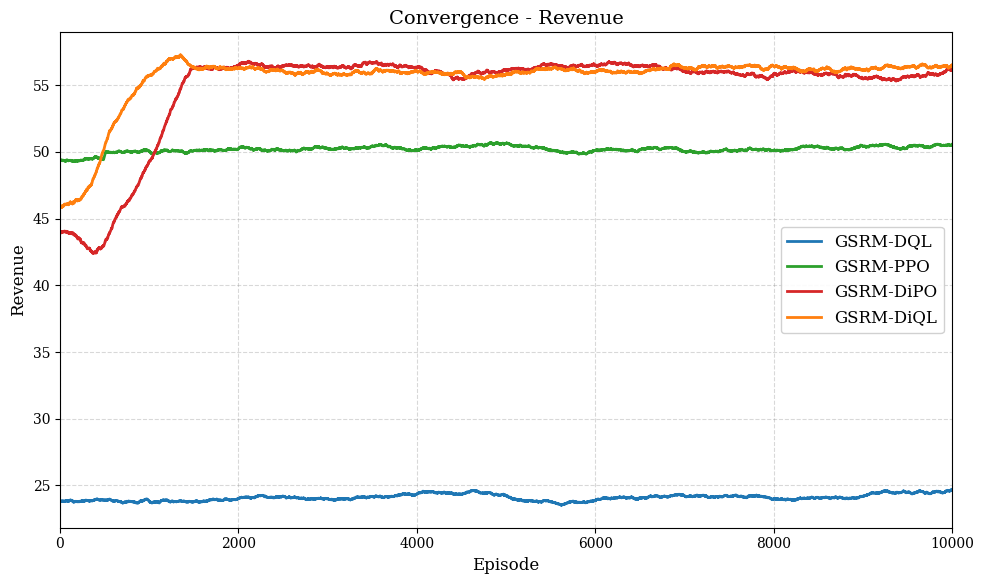

Saved: /home/n2tp/projects/Khanh_stuff/DRL-Memory-Maximize-Problem/plots/convergence/save_figs/25/convergence_revenue_overlay_qos_30.0_u8.png


In [3]:
def load_episode_metrics(run_dir):
    file_path = run_dir / f"convergence_metrics_qos_{qos_required}_users_{num_users}.json"
    if not file_path.exists():
        return [], {}
    try:
        with open(file_path, "r") as f:
            data = json.load(f)
    except json.JSONDecodeError as e:
        print(f"⚠️  Skip {file_path} (invalid JSON: line {e.lineno}, col {e.colno})")
        return [], {}
    except Exception as e:  # catch-all to avoid breaking plotting when a file is corrupted
        print(f"⚠️  Skip {file_path} (error: {e})")
        return [], {}
    episodes = []
    metrics = {"mean_latency": [], "qos_scores": [], "peaked_mem": [], "total_revenue": []}
    for ep in data.get("episode_metrics", []):
        episodes.append(int(ep.get("episode", len(episodes) + 1)))
        final_info = ep.get("final_info", {})
        metrics["mean_latency"].append(float(final_info.get("mean_latency", 0.0)))
        metrics["qos_scores"].append(float(final_info.get("qos_scores", 0.0)))
        metrics["peaked_mem"].append(float(final_info.get("peaked_mem", 0.0)))
        metrics["total_revenue"].append(float(final_info.get("total_revenue", 0.0)))
    return episodes, metrics

def plot_overlay(all_runs, episodes_map, output_dir, smooth_window):
    output_dir.mkdir(parents=True, exist_ok=True)
    metrics_keys = [
        # ("mean_latency", "Latency (s)", "latency"),
        # ("qos_scores", "QoS Score", "qos"),
        # ("peaked_mem", "Peak Memory", "memory"),
        ("total_revenue", "Revenue", "revenue"),
    ]
    
    # Use colors from configuration
    run_names = list(all_runs.keys())
    colors_list = []
    for run_name in run_names:
        if run_name in colors_dict:
            colors_list.append(colors_dict[run_name])
        else:
            # Fallback to matplotlib default colors if algorithm not in config
            colors_list.append(plt.cm.tab10(len(colors_list) % 10))
    
    print("Colors: ", colors_list)
    for key, ylabel, short in metrics_keys:
        fig, ax = plt.subplots(figsize=(10, 6))
        for idx, (run_name, metrics) in enumerate(all_runs.items()):
            values = metrics.get(key, [])
            episodes = episodes_map.get(run_name, [])
            if not values or not episodes:
                continue
            smoothed = smooth_rewards(values, smooth_window)
            if len(smoothed) > 0 and len(smoothed) != len(values):
                smoothed_x = episodes[smooth_window - 1 :]
            else:
                smoothed_x = episodes
            ax.plot(smoothed_x, smoothed, label=get_algorithm_display_name(run_name), 
                   color=colors_list[idx], linewidth=2.0)
        ax.set_xlabel("Episode")
        ax.set_ylabel(ylabel)
        ax.set_title(f"Convergence - {ylabel}")
        ax.grid(True, alpha=0.3)
        ax.set_xlim(0, max(max(episodes_map.get(rn, [0])) for rn in all_runs.keys()) if all_runs else 1)
        ax.legend()
        plt.tight_layout()
        save_path = output_dir / f"convergence_{short}_overlay_qos_{qos_required}_u{num_users}.png"
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
        plt.show()
        plt.close(fig)
        print(f"Saved: {save_path}")


logs_dir="logs"
output_dir="../plots/convergence"
smooth_window=1000
overlay_only=True
num_users=8
qos_required=30.0
seed=25
logs_dir = Path(f"/home/n2tp/projects/Khanh_stuff/DRL-Memory-Maximize-Problem/logs/{seed}")
output_dir = Path(output_dir).expanduser().resolve() / "save_figs" / f"{seed}"
if not logs_dir.exists():
    raise FileNotFoundError(f"Logs directory not found: {logs_dir}")
all_runs = {}
episodes_map = {}
for run_dir in sorted(logs_dir.iterdir()):
    if not run_dir.is_dir():
        continue
    episodes, metrics = load_episode_metrics(run_dir, )
    if not episodes:
        continue
    run_name = run_dir.name
    all_runs[run_name] = metrics
    episodes_map[run_name] = episodes
if not all_runs:
    print("No convergence_metrics.json files found.")


plot_overlay(all_runs, episodes_map, output_dir, smooth_window)





In [4]:
# Load convergence metrics for all parameter combinations
from pathlib import Path

seed = 45
logs_dir = Path(f"/home/n2tp/projects/Khanh_stuff/DRL-Memory-Maximize-Problem/logs/{seed}")

qos_required_list = [25.0, 30.0, 35.0]
num_users_list = [8, 10, 12]
M_max_list = [32, 48, 64]

convergence_data = {}

for folder in sorted(logs_dir.iterdir()):
    if not folder.is_dir():
        continue
    
    for M_max in M_max_list:
        for qos in qos_required_list:
            for users in num_users_list:
                
                convergence_data \
                    .setdefault(folder.name, {}) \
                    .setdefault(str(qos), {}) \
                    .setdefault(str(users), {}) \
                    .setdefault(str(M_max), {'episodes': [], 'revenue': []})
                
                metrics_file = folder / (
                    f"convergence_metrics_qos_{float(qos)}_users_{users}_Mmax_{M_max}.json"
                )
                
                if metrics_file.exists():
                    try:
                        with open(metrics_file, "r") as f:
                            data = json.load(f)
                            episodes = []
                            revenues = []
                            for ep in data.get("episode_metrics", []):
                                episodes.append(int(ep.get("episode", len(episodes) + 1)))
                                final_info = ep.get("final_info", {})
                                revenues.append(float(final_info.get("total_revenue", 0.0)))
                            
                            convergence_data[folder.name][str(qos)][str(users)][str(M_max)] = {
                                'episodes': episodes,
                                'revenue': revenues
                            }
                    except Exception as e:
                        print(f"⚠️  Skip {metrics_file} (error: {e})")
                else:
                    print(f"✗ File not found: {metrics_file}")

print("✓ Convergence data loaded successfully!")
print(f"Algorithms: {list(convergence_data.keys())}")

✓ Convergence data loaded successfully!
Algorithms: ['gaussian_dql', 'gaussian_ppo', 'ppo_diffusion', 'ql_diffusion']


In [5]:
# Color scheme for different configurations (same as exp4.ipynb)
colors_config = {
     'ql_diffusion': {
        '25.0': {'8': 
                    {'32':'#B8860B', '48':'#B8860B', '64':'#B8860B'},    
                '10': 
                    {'32':'#FFD700', '48':'#FFD700', '64':'#FFD700'},      
               '12': 
                    {'32':"#C2C276", '48':'#C2C276', '64':'#C2C276'}},    
        '30.0': {'8': 
                    {'32':'#B8860B', '48':'#B8860B', '64':'#B8860B'},    
               '10': 
                    {'32':'#FFD700', '48':'#FFD700', '64':'#FFD700'},   
               '12': 
                    {'32':'#C2C276', '48':'#C2C276', '64':'#C2C276'}}, 
        '35.0': {'8':
                    {'32':'#B8860B', '48':'#B8860B', '64':'#B8860B'}, 
               '10': 
                    {'32':'#FFD700', '48':'#FFD700', '64':'#FFD700'},
               '12':
                    {'32':'#C2C276', '48':'#C2C276', '64':'#C2C276'}},    
    },
    'ppo_diffusion': {
        '25.0': {'8': 
                    {'32':'#8B0000', '48':'#8B0000', '64':'#8B0000'},    
               '10': 
                    {'32':'#FF0000', '48':'#FF0000', '64':'#FF0000'},   
               '12': 
                    {'32':'#F08080', '48':'#F08080', '64':'#F08080'}}, 
        '30.0': {'8': 
                    {'32':'#8B0000', '48':'#8B0000', '64':'#8B0000'}, 
               '10': 
                    {'32':'#FF0000', '48':'#FF0000', '64':'#FF0000'},
               '12': 
                    {'32':'#F08080', '48':'#F08080', '64':'#F08080'}},     
        '35.0': {'8': 
                    {'32':'#8B0000', '48':'#8B0000', '64':'#8B0000'},    
               '10': 
                    {'32':'#FF0000', '48':'#FF0000', '64':'#FF0000'},   
               '12': 
                    {'32':'#F08080', '48':'#F08080', '64':'#F08080'}}, 
    },
    'gaussian_ppo': {
        '25.0': {'8': 
                    {'32':'#00008B', '48':'#00008B', '64':'#00008B'},  
               '10':
                    {'32':'#1E90FF', '48':'#1E90FF', '64':'#1E90FF'},   
               '12':     
                    {'32':'#4682B4', '48':'#4682B4', '64':'#4682B4'}}, 
        '30.0': {'8': 
                    {'32':'#00008B', '48':'#00008B', '64':'#00008B'}, 
               '10': 
                    {'32':'#1E90FF', '48':'#1E90FF', '64':'#1E90FF'},  
               '12': 
                    {'32':'#4682B4', '48':'#4682B4', '64':'#4682B4'}},
        '35.0': {'8': 
                    {'32':'#00008B', '48':'#00008B', '64':'#00008B'}, 
               '10': 
                    {'32':'#1E90FF', '48':'#1E90FF', '64':'#1E90FF'}, 
               '12': 
                    {'32':'#4682B4', '48':'#4682B4', '64':'#4682B4'}},
    },
    'gaussian_dql': {
        '25.0': {'8': 
                    {'32': '#006400', '48': '#006400', '64': '#006400'},   
               '10': 
                    {'32': '#32CD32', '48': '#32CD32', '64': '#32CD32'},   
               '12': 
                    {'32': '#90EE90', '48': '#90EE90', '64': '#90EE90'}}, 
        '30.0': {'8': 
                    {'32': '#228B22', '48': '#228B22', '64': '#228B22'},
               '10': 
                    {'32': '#00FF00', '48': '#00FF00', '64': '#00FF00'}, 
               '12': 
                    {'32': '#98FB98', '48': '#98FB98', '64': '#98FB98'}},
        '35.0': {'8': 
                    {'32': '#2E8B57', '48': '#2E8B57', '64': '#2E8B57'},
               '10': 
                    {'32': '#00FA9A', '48': '#00FA9A', '64': '#00FA9A'}, 
               '12': 
                    {'32': '#AFEEEE', '48': '#AFEEEE', '64': '#AFEEEE'}},
    },
}

linestyles_config = {
    32: '-',
    48: '--',
    64: ':'
}

print("✓ Color and linestyle configuration loaded!")

✓ Color and linestyle configuration loaded!


In [6]:
import os


def plot_revenue_convergence(
    convergence_data,
    qos_list=[30.0],
    users_list=[8, 10, 12],
    Mmax_list=[32, 48, 64],
    is_out=False,
    colors=colors_config,
    window=500,
    linestyles=linestyles_config,
    figsize=(8, 5),
    save_path=None
):
    """
    Plot revenue convergence for different configurations
    
    Parameters:
    - convergence_data: nested dict with algorithm/qos/users/Mmax/episodes,revenue
    - qos_list: list of QoS values to plot
    - users_list: list of user counts to plot
    - Mmax_list: list of M_max values to plot
    - is_out: if True, legend outside plot area
    - window: smoothing window size
    - figsize: figure size tuple
    - save_path: path to save figure (if None, just display)
    """
    plt.figure(figsize=figsize)
    plot_data = {}  # Store all processed data with labels as keys
    
    for qos in qos_list:
        for users in users_list:
            for m in Mmax_list:
                for alg_name in convergence_data.keys():
                    
                    config_data = convergence_data[alg_name][str(qos)][str(users)][str(m)]
                    episodes = config_data.get('episodes', [])
                    revenues = config_data.get('revenue', [])
                    
                    if alg_name == 'ppo_diffusion':
                        revenues = [rev + 10 for rev in revenues] 
                    
                    if not episodes or not revenues:
                        continue
                    
                    # Apply smoothing
                    smoothed_revenue = smooth_rewards(revenues, window)
                    
                    # Adjust x-axis for smoothing
                    if len(smoothed_revenue) > 0 and len(smoothed_revenue) != len(revenues):
                        smoothed_x = episodes[window - 1:]
                    else:
                        smoothed_x = episodes
                    
                    label = rf"{get_algorithm_display_name(alg_name)} ($\mathcal{{M}}_{{max}}$={m}, $N$={users}, $\mathcal{{Q}}_1^{{req}}$={qos})"
                    
                    # Store processed data for later use
                    plot_data[label] = {
                        'algorithm': alg_name,
                        'qos': qos,
                        'users': users,
                        'mmax': m,
                        'episodes': smoothed_x.tolist() if hasattr(smoothed_x, 'tolist') else smoothed_x,
                        'revenue': smoothed_revenue.tolist() if hasattr(smoothed_revenue, 'tolist') else smoothed_revenue,
                    }
                    print(f"Mmax: {m}, Users: {users}, QoS: {qos}, Alg: {alg_name} → avg revenue: {np.mean(smoothed_revenue):.2f}")
                    
                    plt.plot(
                        smoothed_x,
                        smoothed_revenue,
                        label=label,
                        color=colors[alg_name][str(qos)][str(users)][str(m)],
                        # linestyle=linestyles[m],
                        alpha=0.8,
                        linewidth=2.0
                    )
    
    plt.xlabel("Episode")
    plt.ylabel("Revenue")
    plt.xlim(0, 10000)
    # plt.title("Revenue Convergence")
    plt.grid(True, alpha=0.3)
    
    if is_out:
        plt.legend(fontsize=9, loc="center left", bbox_to_anchor=(1, 0.5))
    else:
        plt.legend(fontsize=9, loc="best", framealpha=0.9)
    
    plt.tight_layout()
    
    if save_path:
        os.makedirs(Path(save_path).parent, exist_ok=True)
        
        # # Save figure
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✓ Saved figure: {save_path}")
        
        # Save data as JSON for later use
        json_path = Path(save_path).with_suffix('.json')
        with open(json_path, 'w') as f:
            json.dump(plot_data, f, indent=4)
        print(f"✓ Saved data: {json_path}")
    
    plt.show()
    
    return plot_data  # Return data for further analysis if needed

print("✓ Plotting function defined!")

✓ Plotting function defined!


Plotting revenue convergence by NUMBER OF USERS

📊 Plotting for N=8 users...
Mmax: 32, Users: 8, QoS: 30.0, Alg: gaussian_dql → avg revenue: 36.51
Mmax: 32, Users: 8, QoS: 30.0, Alg: gaussian_ppo → avg revenue: 38.50
Mmax: 32, Users: 8, QoS: 30.0, Alg: ppo_diffusion → avg revenue: 53.71
Mmax: 32, Users: 8, QoS: 30.0, Alg: ql_diffusion → avg revenue: 44.07
Mmax: 48, Users: 8, QoS: 30.0, Alg: gaussian_dql → avg revenue: 37.27
Mmax: 48, Users: 8, QoS: 30.0, Alg: gaussian_ppo → avg revenue: 39.69
Mmax: 48, Users: 8, QoS: 30.0, Alg: ppo_diffusion → avg revenue: 64.63
Mmax: 48, Users: 8, QoS: 30.0, Alg: ql_diffusion → avg revenue: 55.78
Mmax: 64, Users: 8, QoS: 30.0, Alg: gaussian_dql → avg revenue: 37.44
Mmax: 64, Users: 8, QoS: 30.0, Alg: gaussian_ppo → avg revenue: 39.69
Mmax: 64, Users: 8, QoS: 30.0, Alg: ppo_diffusion → avg revenue: 65.71
Mmax: 64, Users: 8, QoS: 30.0, Alg: ql_diffusion → avg revenue: 56.77


✓ Saved figure: ./revenue/revenue_convergence_users_8.png
✓ Saved data: revenue/revenue_convergence_users_8.json


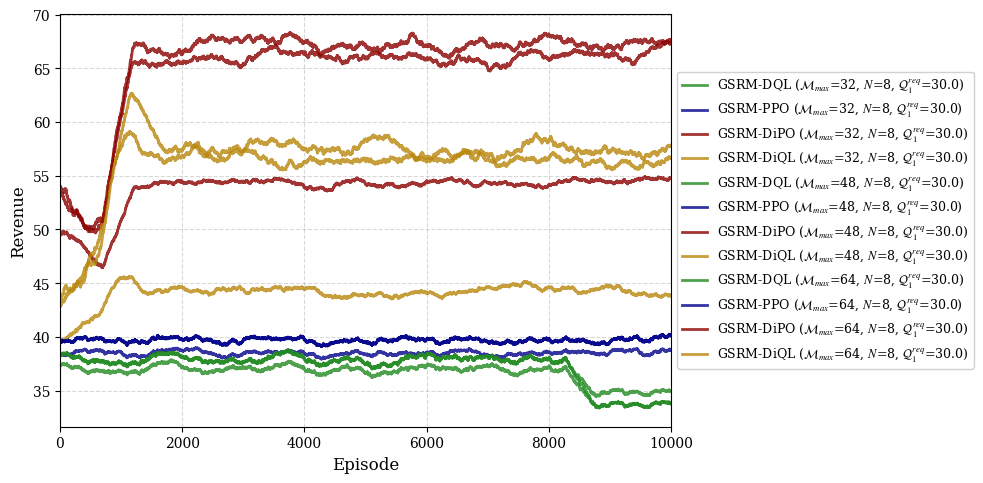


📊 Plotting for N=10 users...
Mmax: 32, Users: 10, QoS: 30.0, Alg: gaussian_dql → avg revenue: 35.81
Mmax: 32, Users: 10, QoS: 30.0, Alg: gaussian_ppo → avg revenue: 40.98
Mmax: 32, Users: 10, QoS: 30.0, Alg: ppo_diffusion → avg revenue: 50.83
Mmax: 32, Users: 10, QoS: 30.0, Alg: ql_diffusion → avg revenue: 41.29
Mmax: 48, Users: 10, QoS: 30.0, Alg: gaussian_dql → avg revenue: 40.20
Mmax: 48, Users: 10, QoS: 30.0, Alg: gaussian_ppo → avg revenue: 55.69
Mmax: 48, Users: 10, QoS: 30.0, Alg: ppo_diffusion → avg revenue: 68.30
Mmax: 48, Users: 10, QoS: 30.0, Alg: ql_diffusion → avg revenue: 59.21
Mmax: 64, Users: 10, QoS: 30.0, Alg: gaussian_dql → avg revenue: 43.76
Mmax: 64, Users: 10, QoS: 30.0, Alg: gaussian_ppo → avg revenue: 56.77
Mmax: 64, Users: 10, QoS: 30.0, Alg: ppo_diffusion → avg revenue: 76.21
Mmax: 64, Users: 10, QoS: 30.0, Alg: ql_diffusion → avg revenue: 67.75
✓ Saved figure: ./revenue/revenue_convergence_users_10.png
✓ Saved data: revenue/revenue_convergence_users_10.json


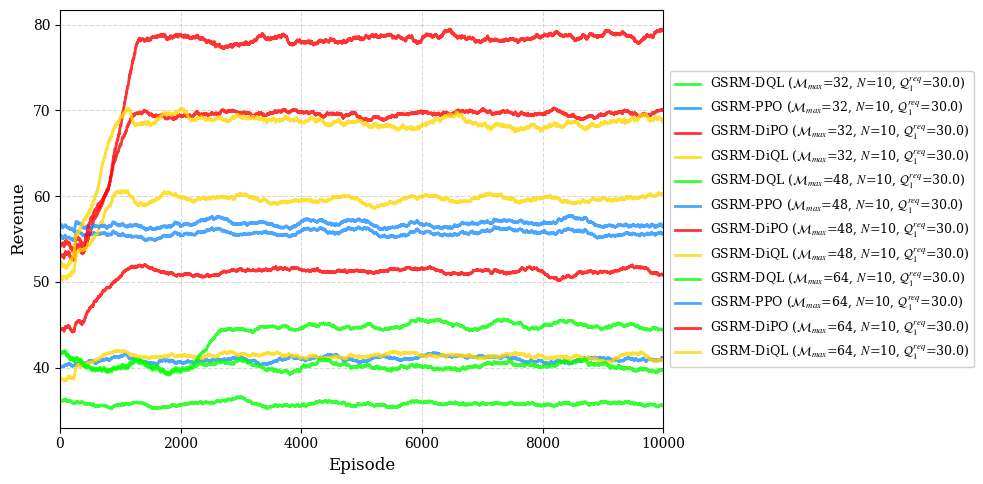


📊 Plotting for N=12 users...
Mmax: 32, Users: 12, QoS: 30.0, Alg: gaussian_dql → avg revenue: 32.58
Mmax: 32, Users: 12, QoS: 30.0, Alg: gaussian_ppo → avg revenue: 37.44
Mmax: 32, Users: 12, QoS: 30.0, Alg: ppo_diffusion → avg revenue: 47.73
Mmax: 32, Users: 12, QoS: 30.0, Alg: ql_diffusion → avg revenue: 37.86
Mmax: 48, Users: 12, QoS: 30.0, Alg: gaussian_dql → avg revenue: 56.10
Mmax: 48, Users: 12, QoS: 30.0, Alg: gaussian_ppo → avg revenue: 47.62
Mmax: 48, Users: 12, QoS: 30.0, Alg: ppo_diffusion → avg revenue: 63.68
Mmax: 48, Users: 12, QoS: 30.0, Alg: ql_diffusion → avg revenue: 54.07
Mmax: 64, Users: 12, QoS: 30.0, Alg: gaussian_dql → avg revenue: 34.42
Mmax: 64, Users: 12, QoS: 30.0, Alg: gaussian_ppo → avg revenue: 48.70
Mmax: 64, Users: 12, QoS: 30.0, Alg: ppo_diffusion → avg revenue: 74.51
Mmax: 64, Users: 12, QoS: 30.0, Alg: ql_diffusion → avg revenue: 65.35
✓ Saved figure: ./revenue/revenue_convergence_users_12.png
✓ Saved data: revenue/revenue_convergence_users_12.json


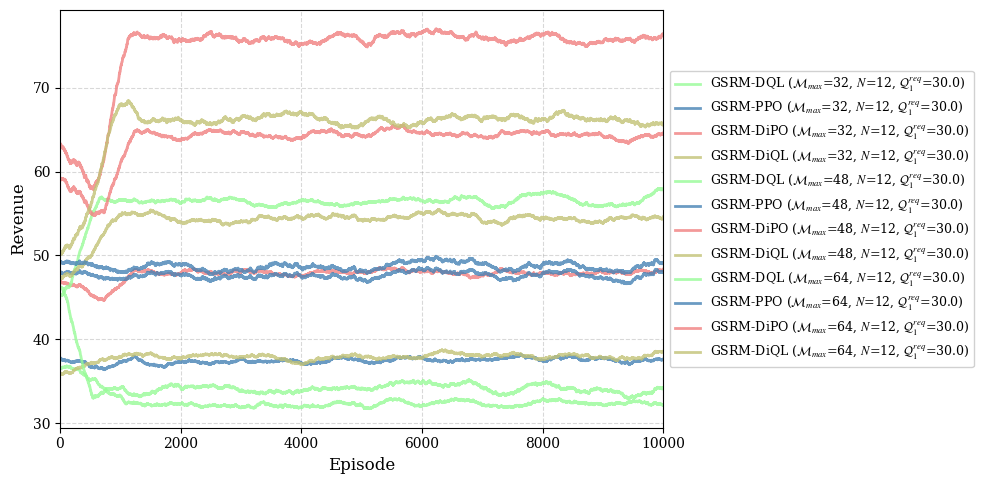

In [7]:
# Plot 1: Revenue convergence for different number of users (fixed QoS=30.0)
print("=" * 60)
print("Plotting revenue convergence by NUMBER OF USERS")
print("=" * 60)

qos_list = [30.0]
users_list = [8, 10, 12]
M_max_list = [32, 48, 64]

for u in users_list:
    print(f"\n📊 Plotting for N={u} users...")
    plot_revenue_convergence(
        convergence_data,
        qos_list=[30.0],
        users_list=[u],
        Mmax_list=M_max_list,
        is_out=True,
        figsize=(10, 5),
        save_path=f"./revenue/revenue_convergence_users_{u}.png"
    )

Plotting revenue convergence by QoS REQUIREMENTS

📊 Plotting for QoS=25.0...
Mmax: 32, Users: 10, QoS: 25.0, Alg: gaussian_dql → avg revenue: 35.81
Mmax: 32, Users: 10, QoS: 25.0, Alg: gaussian_ppo → avg revenue: 40.98
Mmax: 32, Users: 10, QoS: 25.0, Alg: ppo_diffusion → avg revenue: 50.79
Mmax: 32, Users: 10, QoS: 25.0, Alg: ql_diffusion → avg revenue: 41.30
Mmax: 48, Users: 10, QoS: 25.0, Alg: gaussian_dql → avg revenue: 44.42
Mmax: 48, Users: 10, QoS: 25.0, Alg: gaussian_ppo → avg revenue: 55.69
Mmax: 48, Users: 10, QoS: 25.0, Alg: ppo_diffusion → avg revenue: 68.16
Mmax: 48, Users: 10, QoS: 25.0, Alg: ql_diffusion → avg revenue: 59.15
Mmax: 64, Users: 10, QoS: 25.0, Alg: gaussian_dql → avg revenue: 40.36
Mmax: 64, Users: 10, QoS: 25.0, Alg: gaussian_ppo → avg revenue: 56.77
Mmax: 64, Users: 10, QoS: 25.0, Alg: ppo_diffusion → avg revenue: 76.61
Mmax: 64, Users: 10, QoS: 25.0, Alg: ql_diffusion → avg revenue: 67.52
✓ Saved figure: ./revenue/revenue_convergence_qos_25.0.png
✓ Saved d

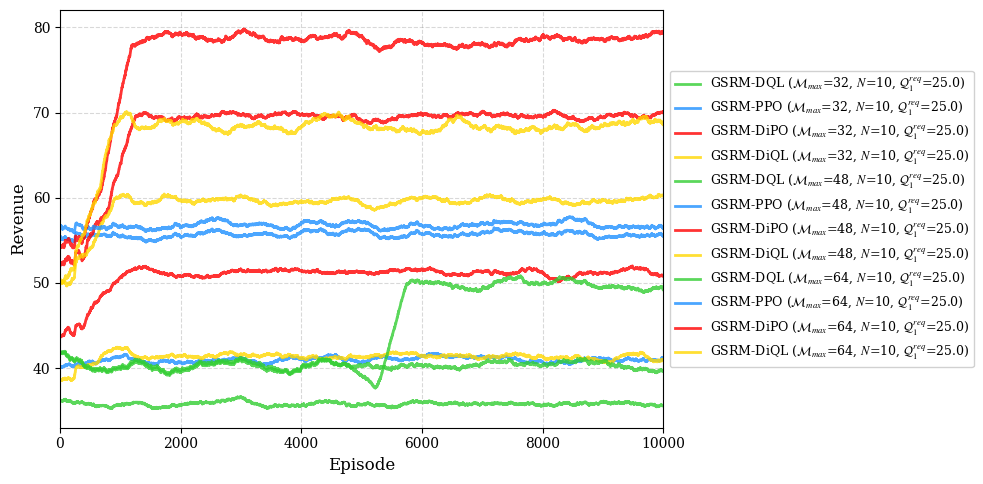


📊 Plotting for QoS=30.0...
Mmax: 32, Users: 10, QoS: 30.0, Alg: gaussian_dql → avg revenue: 35.81
Mmax: 32, Users: 10, QoS: 30.0, Alg: gaussian_ppo → avg revenue: 40.98
Mmax: 32, Users: 10, QoS: 30.0, Alg: ppo_diffusion → avg revenue: 50.83
Mmax: 32, Users: 10, QoS: 30.0, Alg: ql_diffusion → avg revenue: 41.29
Mmax: 48, Users: 10, QoS: 30.0, Alg: gaussian_dql → avg revenue: 40.20
Mmax: 48, Users: 10, QoS: 30.0, Alg: gaussian_ppo → avg revenue: 55.69
Mmax: 48, Users: 10, QoS: 30.0, Alg: ppo_diffusion → avg revenue: 68.30
Mmax: 48, Users: 10, QoS: 30.0, Alg: ql_diffusion → avg revenue: 59.21
Mmax: 64, Users: 10, QoS: 30.0, Alg: gaussian_dql → avg revenue: 43.76
Mmax: 64, Users: 10, QoS: 30.0, Alg: gaussian_ppo → avg revenue: 56.77
Mmax: 64, Users: 10, QoS: 30.0, Alg: ppo_diffusion → avg revenue: 76.21
Mmax: 64, Users: 10, QoS: 30.0, Alg: ql_diffusion → avg revenue: 67.75
✓ Saved figure: ./revenue/revenue_convergence_qos_30.0.png
✓ Saved data: revenue/revenue_convergence_qos_30.0.json


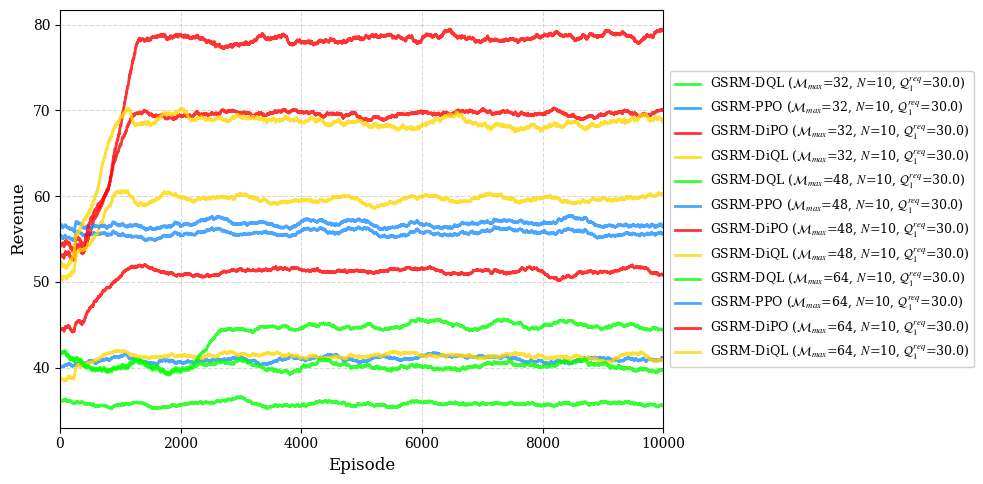


📊 Plotting for QoS=35.0...
Mmax: 32, Users: 10, QoS: 35.0, Alg: gaussian_dql → avg revenue: 35.81
Mmax: 32, Users: 10, QoS: 35.0, Alg: gaussian_ppo → avg revenue: 40.98
Mmax: 32, Users: 10, QoS: 35.0, Alg: ppo_diffusion → avg revenue: 50.81
Mmax: 32, Users: 10, QoS: 35.0, Alg: ql_diffusion → avg revenue: 41.28
Mmax: 48, Users: 10, QoS: 35.0, Alg: gaussian_dql → avg revenue: 40.20
Mmax: 48, Users: 10, QoS: 35.0, Alg: gaussian_ppo → avg revenue: 55.69
Mmax: 48, Users: 10, QoS: 35.0, Alg: ppo_diffusion → avg revenue: 68.26
Mmax: 48, Users: 10, QoS: 35.0, Alg: ql_diffusion → avg revenue: 59.16
Mmax: 64, Users: 10, QoS: 35.0, Alg: gaussian_dql → avg revenue: 40.36
Mmax: 64, Users: 10, QoS: 35.0, Alg: gaussian_ppo → avg revenue: 56.77
Mmax: 64, Users: 10, QoS: 35.0, Alg: ppo_diffusion → avg revenue: 76.55
Mmax: 64, Users: 10, QoS: 35.0, Alg: ql_diffusion → avg revenue: 67.57
✓ Saved figure: ./revenue/revenue_convergence_qos_35.0.png
✓ Saved data: revenue/revenue_convergence_qos_35.0.json


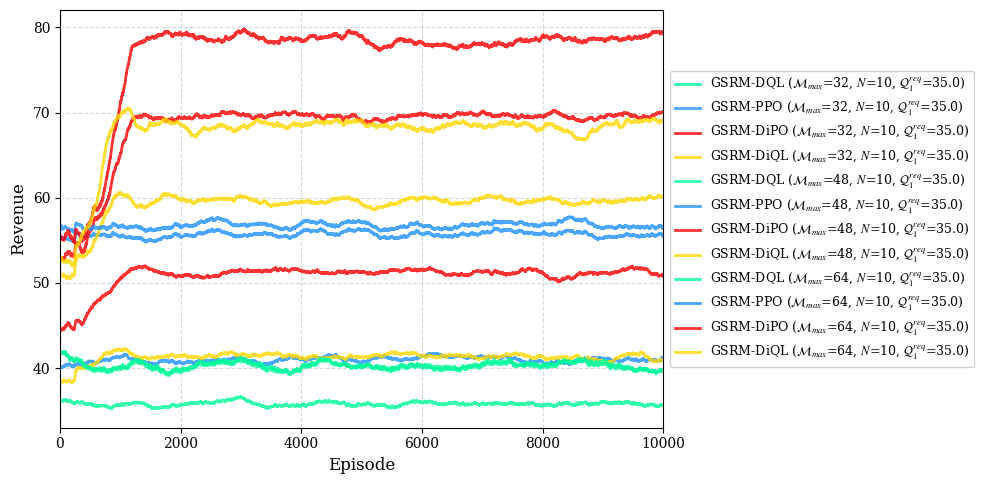

In [8]:
# Plot 2: Revenue convergence for different QoS requirements (fixed users=10)
print("=" * 60)
print("Plotting revenue convergence by QoS REQUIREMENTS")
print("=" * 60)

qos_list = [25.0, 30.0, 35.0]
M_max_list = [32, 48, 64]

for q in qos_list:
    print(f"\n📊 Plotting for QoS={q}...")
    plot_revenue_convergence(
        convergence_data,
        qos_list=[q],
        users_list=[10],
        Mmax_list=M_max_list,
        is_out=True,
        figsize=(10, 5),
        save_path=f"./revenue/revenue_convergence_qos_{q}.png"
    )

Plotting revenue convergence by M_MAX

📊 Plotting for M_max=32...
Mmax: 32, Users: 10, QoS: 30.0, Alg: gaussian_dql → avg revenue: 35.81
Mmax: 32, Users: 10, QoS: 30.0, Alg: gaussian_ppo → avg revenue: 40.98
Mmax: 32, Users: 10, QoS: 30.0, Alg: ppo_diffusion → avg revenue: 50.83
Mmax: 32, Users: 10, QoS: 30.0, Alg: ql_diffusion → avg revenue: 41.29


✓ Saved figure: ./revenue/revenue_convergence_Mmax_32.png
✓ Saved data: revenue/revenue_convergence_Mmax_32.json


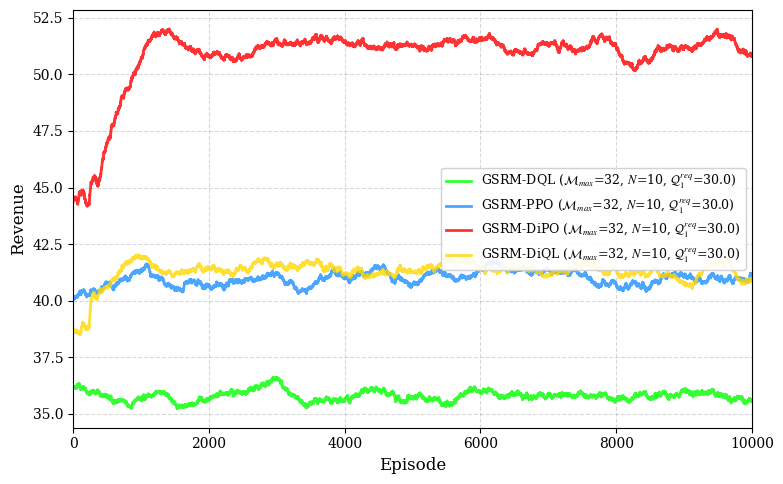


📊 Plotting for M_max=48...
Mmax: 48, Users: 10, QoS: 30.0, Alg: gaussian_dql → avg revenue: 40.20
Mmax: 48, Users: 10, QoS: 30.0, Alg: gaussian_ppo → avg revenue: 55.69
Mmax: 48, Users: 10, QoS: 30.0, Alg: ppo_diffusion → avg revenue: 68.30
Mmax: 48, Users: 10, QoS: 30.0, Alg: ql_diffusion → avg revenue: 59.21
✓ Saved figure: ./revenue/revenue_convergence_Mmax_48.png
✓ Saved data: revenue/revenue_convergence_Mmax_48.json


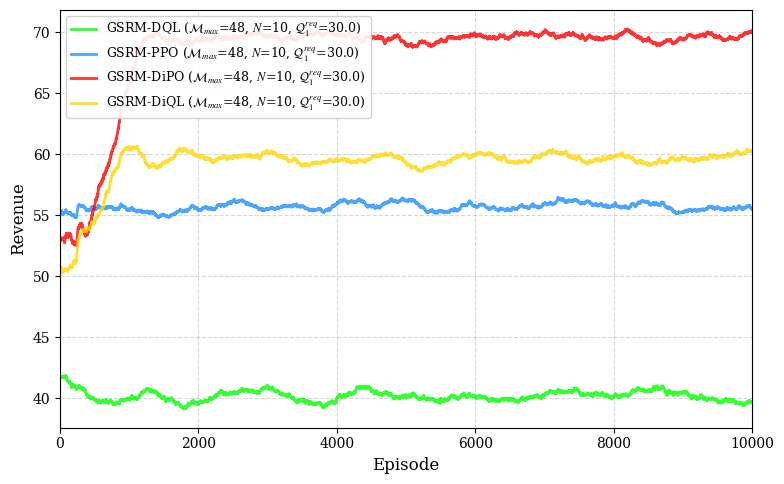


📊 Plotting for M_max=64...
Mmax: 64, Users: 10, QoS: 30.0, Alg: gaussian_dql → avg revenue: 43.76
Mmax: 64, Users: 10, QoS: 30.0, Alg: gaussian_ppo → avg revenue: 56.77
Mmax: 64, Users: 10, QoS: 30.0, Alg: ppo_diffusion → avg revenue: 76.21
Mmax: 64, Users: 10, QoS: 30.0, Alg: ql_diffusion → avg revenue: 67.75
✓ Saved figure: ./revenue/revenue_convergence_Mmax_64.png
✓ Saved data: revenue/revenue_convergence_Mmax_64.json


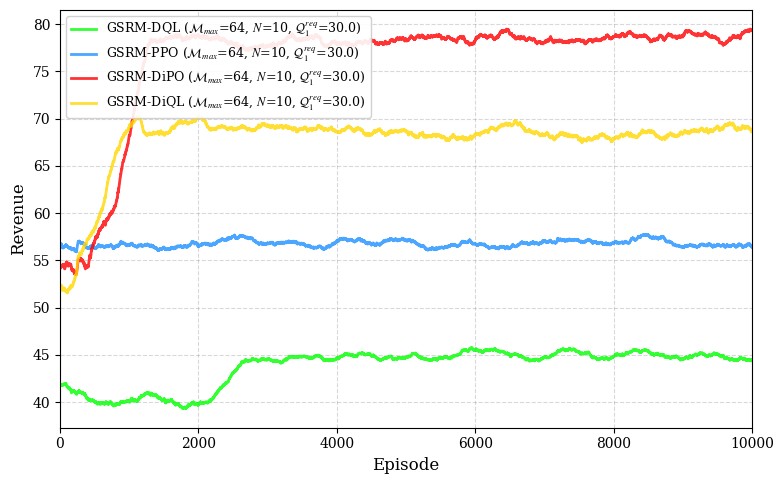

In [9]:
# Plot 3: Revenue convergence for different M_max values (fixed QoS=30.0, users=10)
print("=" * 60)
print("Plotting revenue convergence by M_MAX")
print("=" * 60)

M_max_list = [32, 48, 64]

for m in M_max_list:
    print(f"\n📊 Plotting for M_max={m}...")
    plot_revenue_convergence(
        convergence_data,
        qos_list=[30.0],
        users_list=[10],
        Mmax_list=[m],
        is_out=False,
        figsize=(8, 5),
        save_path=f"./revenue/revenue_convergence_Mmax_{m}.png"
    )

Plotting COMBINED COMPARISON

📊 Combined plot: All M_max values, all users (QoS=30.0)...
Mmax: 48, Users: 8, QoS: 30.0, Alg: gaussian_dql → avg revenue: 37.27
Mmax: 48, Users: 8, QoS: 30.0, Alg: gaussian_ppo → avg revenue: 39.69
Mmax: 48, Users: 8, QoS: 30.0, Alg: ppo_diffusion → avg revenue: 64.63
Mmax: 48, Users: 8, QoS: 30.0, Alg: ql_diffusion → avg revenue: 55.78
Mmax: 48, Users: 10, QoS: 30.0, Alg: gaussian_dql → avg revenue: 40.20
Mmax: 48, Users: 10, QoS: 30.0, Alg: gaussian_ppo → avg revenue: 55.69
Mmax: 48, Users: 10, QoS: 30.0, Alg: ppo_diffusion → avg revenue: 68.30
Mmax: 48, Users: 10, QoS: 30.0, Alg: ql_diffusion → avg revenue: 59.21
Mmax: 48, Users: 12, QoS: 30.0, Alg: gaussian_dql → avg revenue: 56.10
Mmax: 48, Users: 12, QoS: 30.0, Alg: gaussian_ppo → avg revenue: 47.62
Mmax: 48, Users: 12, QoS: 30.0, Alg: ppo_diffusion → avg revenue: 63.68
Mmax: 48, Users: 12, QoS: 30.0, Alg: ql_diffusion → avg revenue: 54.07


✓ Saved figure: ./revenue/revenue_convergence_all_users.png
✓ Saved data: revenue/revenue_convergence_all_users.json


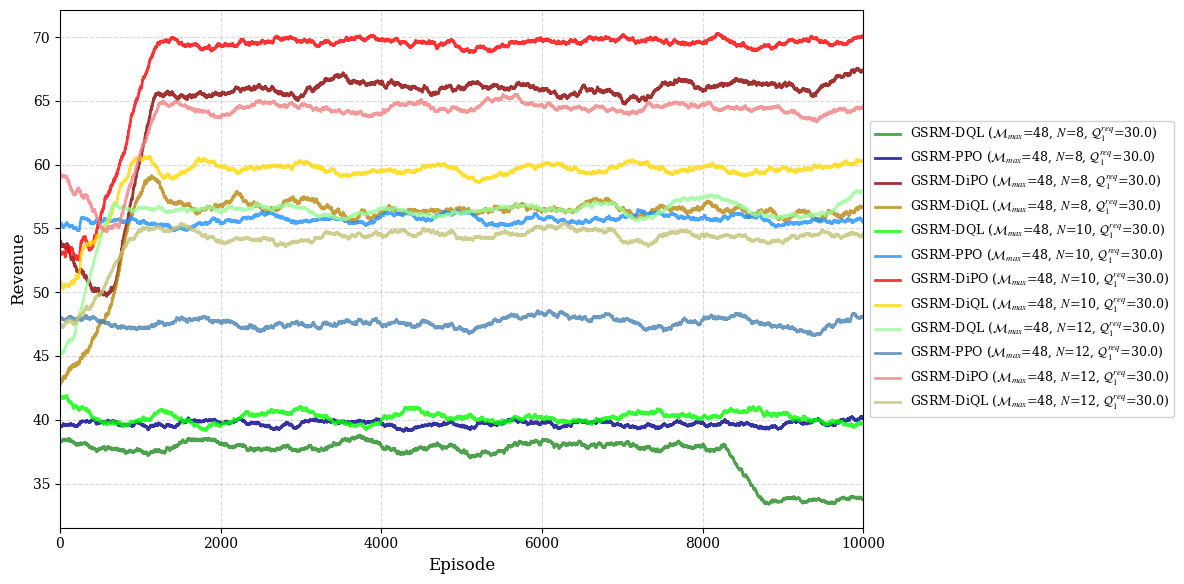

{'GSRM-DQL ($\\mathcal{M}_{max}$=48, $N$=8, $\\mathcal{Q}_1^{req}$=30.0)': {'algorithm': 'gaussian_dql',
  'qos': 30.0,
  'users': 8,
  'mmax': 48,
  'episodes': [1,
   2,
   3,
   4,
   5,
   6,
   7,
   8,
   9,
   10,
   11,
   12,
   13,
   14,
   15,
   16,
   17,
   18,
   19,
   20,
   21,
   22,
   23,
   24,
   25,
   26,
   27,
   28,
   29,
   30,
   31,
   32,
   33,
   34,
   35,
   36,
   37,
   38,
   39,
   40,
   41,
   42,
   43,
   44,
   45,
   46,
   47,
   48,
   49,
   50,
   51,
   52,
   53,
   54,
   55,
   56,
   57,
   58,
   59,
   60,
   61,
   62,
   63,
   64,
   65,
   66,
   67,
   68,
   69,
   70,
   71,
   72,
   73,
   74,
   75,
   76,
   77,
   78,
   79,
   80,
   81,
   82,
   83,
   84,
   85,
   86,
   87,
   88,
   89,
   90,
   91,
   92,
   93,
   94,
   95,
   96,
   97,
   98,
   99,
   100,
   101,
   102,
   103,
   104,
   105,
   106,
   107,
   108,
   109,
   110,
   111,
   112,
   113,
   114,
   115,
   116,
   117,
   118,
   1

In [10]:
# Plot 4: Combined comparison - all algorithms, all M_max, varying users
print("=" * 60)
print("Plotting COMBINED COMPARISON")
print("=" * 60)

# All users, single QoS
print("\n📊 Combined plot: All M_max values, all users (QoS=30.0)...")
plot_revenue_convergence(
    convergence_data,
    qos_list=[30.0],
    users_list=[8, 10, 12],
    Mmax_list=[48],
    is_out=True,
    figsize=(12, 6),
    save_path=f"./revenue/revenue_convergence_all_users.png"
)


📊 Combined plot: All M_max values, all QoS (users=10)...
Mmax: 48, Users: 10, QoS: 25.0, Alg: gaussian_dql → avg revenue: 44.42
Mmax: 48, Users: 10, QoS: 25.0, Alg: gaussian_ppo → avg revenue: 55.69
Mmax: 48, Users: 10, QoS: 25.0, Alg: ppo_diffusion → avg revenue: 68.16
Mmax: 48, Users: 10, QoS: 25.0, Alg: ql_diffusion → avg revenue: 59.15
Mmax: 48, Users: 10, QoS: 30.0, Alg: gaussian_dql → avg revenue: 40.20
Mmax: 48, Users: 10, QoS: 30.0, Alg: gaussian_ppo → avg revenue: 55.69
Mmax: 48, Users: 10, QoS: 30.0, Alg: ppo_diffusion → avg revenue: 68.30
Mmax: 48, Users: 10, QoS: 30.0, Alg: ql_diffusion → avg revenue: 59.21
Mmax: 48, Users: 10, QoS: 35.0, Alg: gaussian_dql → avg revenue: 40.20
Mmax: 48, Users: 10, QoS: 35.0, Alg: gaussian_ppo → avg revenue: 55.69
Mmax: 48, Users: 10, QoS: 35.0, Alg: ppo_diffusion → avg revenue: 68.26
Mmax: 48, Users: 10, QoS: 35.0, Alg: ql_diffusion → avg revenue: 59.16


✓ Saved figure: ./revenue/revenue_convergence_all_qos.png
✓ Saved data: revenue/revenue_convergence_all_qos.json


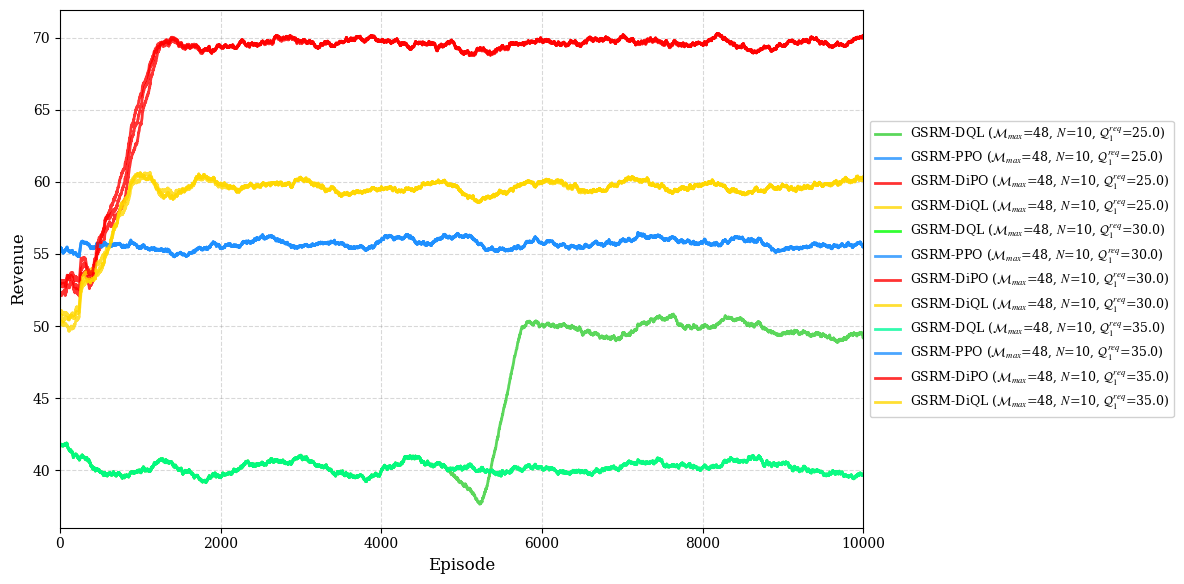


✓ All revenue convergence plots completed!


In [11]:
# Plot 5: Combined comparison - all QoS values (fixed users=10, all M_max)
print("\n📊 Combined plot: All M_max values, all QoS (users=10)...")
plot_revenue_convergence(
    convergence_data,
    qos_list=[25.0, 30.0, 35.0],
    users_list=[10],
    Mmax_list=[48],
    is_out=True,
    figsize=(12, 6),
    save_path=f"./revenue/revenue_convergence_all_qos.png"
)

print("\n" + "=" * 60)
print("✓ All revenue convergence plots completed!")
print("=" * 60)


📊 Combined plot: All M_max values, all QoS (users=10)...
Mmax: 48, Users: 10, QoS: 30.0, Alg: gaussian_dql → avg revenue: 40.20
Mmax: 48, Users: 10, QoS: 30.0, Alg: gaussian_ppo → avg revenue: 55.69
Mmax: 48, Users: 10, QoS: 30.0, Alg: ppo_diffusion → avg revenue: 68.30
Mmax: 48, Users: 10, QoS: 30.0, Alg: ql_diffusion → avg revenue: 59.21


✓ Saved figure: ./revenue/revenue_convergence_all_mmax.png
✓ Saved data: revenue/revenue_convergence_all_mmax.json


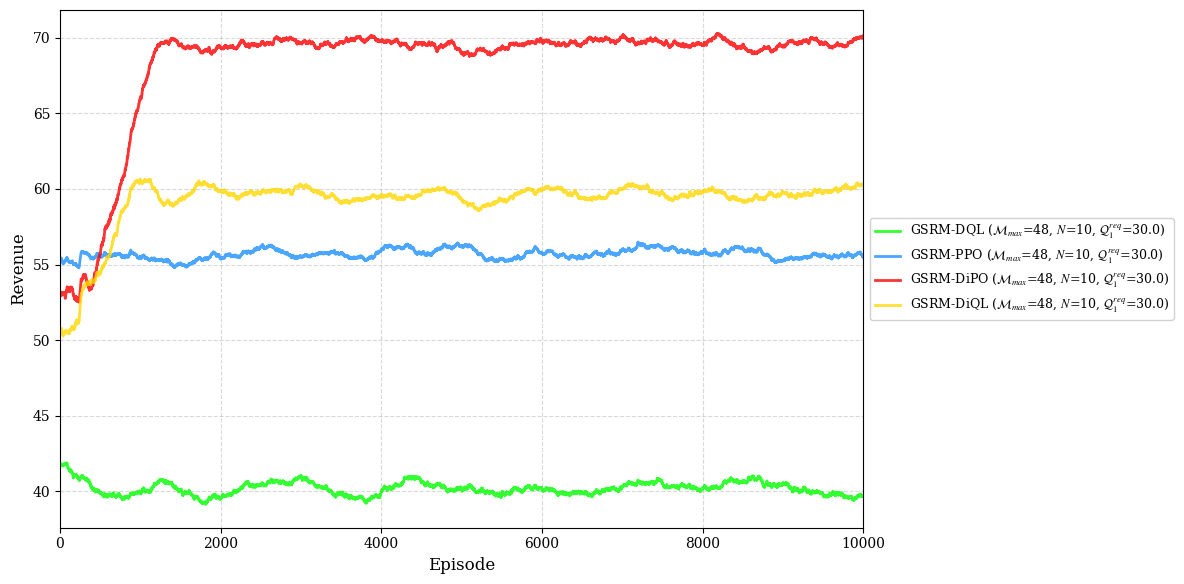


✓ All revenue convergence plots completed!


In [12]:
# Plot 6: Combined comparison - all QoS values (fixed users=10, all M_max)
print("\n📊 Combined plot: All M_max values, all QoS (users=10)...")
plot_revenue_convergence(
    convergence_data,
    qos_list=[30.0],
    users_list=[10],
    Mmax_list=[48],
    is_out=True,
    figsize=(12, 6),
    save_path=f"./revenue/revenue_convergence_all_mmax.png"
)

print("\n" + "=" * 60)
print("✓ All revenue convergence plots completed!")
print("=" * 60)